 ## Quantum 
 ### 3 superconducting Qubits  (Transmon) 

In [18]:
# librerias
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix,negativity,state_fidelity,Operator,concurrence,entropy
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke


from qiskit_dynamics import Solver, Signal
from qiskit_dynamics.backend import parse_backend_hamiltonian_dict

from qiskit import pulse
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import numpy as np
import random
import sympy as sym

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")


In [19]:
import numpy as np
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

def plot_statevector_probabilities(statevector):
    probabilities = statevector.probabilities()
    num_qubits = int(np.log2(len(probabilities)))
    basis_states = [f"|{i:0{num_qubits}b}⟩" for i in range(2**num_qubits)]
    
    plt.figure(figsize=(10, 5))
    plt.bar(basis_states, probabilities, color='royalblue')
    plt.xlabel('Computational basis states')
    plt.ylabel('Probability')
    # plt.title('Measurement Probabilities of Statevector')
    plt.ylim(0, 0.8)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [20]:
backend  = FakeSherbrooke()

propiedades   = backend.properties()
configuracion = backend.configuration()

Hz = 1e9
# frecuencia de los qubits en GHz
w7     = configuracion.hamiltonian.get("vars").get("wq7")
w8     = configuracion.hamiltonian.get("vars").get("wq8")

# anarmonicidad de los qubits en GHz
delta7 = configuracion.hamiltonian.get("vars").get("delta7")
delta8 = configuracion.hamiltonian.get("vars").get("delta8")

# acoples en GHz
J78    = configuracion.hamiltonian.get("vars").get("jq7q8")

# fuerza de control de GHz 
r0     = configuracion.hamiltonian.get("vars").get("omegad7")
r1     = configuracion.hamiltonian.get("vars").get("omegad8") 

# tiempo de gate en ns 
dt     = backend.dt*1e9

In [21]:
propiedades.qubit_property(7,name='frequency')

(4755587722.216813,
 datetime.datetime(2025, 2, 26, 14, 43, 10, tzinfo=tzoffset(None, -18000)))

In [22]:
# tiempo de relajación y decoherencia en segundos
T1_7     = propiedades.qubit_property(7,'T1')[0]  # tiempo de relajación
T2_7     = propiedades.qubit_property(7,'T2')[0]  # tiempo de decoherencia
T1_8     = propiedades.qubit_property(8,'T1')[0]  # tiempo de relajación
T2_8     = propiedades.qubit_property(8,'T2')[0]  # tiempo de decoherencia


# Tiempos T1 y T2 en ns
T1_7 = T1_7*1e9
T2_7 = T2_7*1e9
T1_8 = T1_8*1e9
T2_8 = T2_8*1e9
# gammas de relajación y decoherencia
gamma1_7 = 1/T1_7
gamma2_7 = 1/T2_7 - 1/(2*T1_7)
gamma1_8 = 1/T1_8
gamma2_8 = 1/T2_8 - 1/(2*T1_8)

In [23]:
print(T1_8,T2_8)

394165.10585714877 17282.471331162924


In [24]:
v7     = w7/(2*np.pi) # frecuencia en GHz
v8     = w8/(2*np.pi)  # frecuencia en GHz
# v9     = w9/(2*np.pi)  # frecuencia en GHz  

# estado inicial 
rho_0  = DensityMatrix.from_label("00")

y0 = Statevector.from_label("00")

In [25]:
propiedades.qubit_property(7,name='frequency')

(4755587722.216813,
 datetime.datetime(2025, 2, 26, 14, 43, 10, tzinfo=tzoffset(None, -18000)))

In [26]:
# Definir los operadores 
# dimensión del espacio de Hilbert de cada qubit 
dim        = 2
# operadores de creación, aniquilación y número 
a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident      = np.eye(dim, dtype=complex)
full_indet = np.eye(dim**2, dtype=complex)
# operador número y creación/aniquilación para cada qubit en el sistema de dos qubits
N0         = np.kron(ident,N)
N1         = np.kron(N,ident)

# operador de creación 
a0         = np.kron(ident,a)
a1         = np.kron(a,ident)
# operador de aniquilación
a0dag      = np.kron(ident,adag)
a1dag      = np.kron(adag,ident)

# Haniltoniano del sistema
static_ham = 2*np.pi*v7 * N0  + 2*np.pi*v8 * N1   + J78*(a0dag @ a1 +  a0 @ a1dag) 

# Hamiltonianos de controles
H_drive7 =  r0 * (a0 + a0dag)
H_drive8 =  r1 * (a1 + a1dag)


Z0  = full_indet - 2*N0
Z1  = full_indet - 2*N1

sm1 = a0
sm2 = a1

sz1 = Z0
sz2 = Z1 

collapse_operators = [np.sqrt(gamma1_7)*a0,
                      np.sqrt(gamma1_8)*a1,
                      np.sqrt(gamma2_7)*Z0,
                      np.sqrt(gamma2_8)*Z1]



In [28]:
print(w7, "  ","  ",w8)

29.88023890323631       30.23802708662245


In [29]:
print(J78)

0.012651918734551187


In [30]:
print(r0, "  ", r1)

0.39575797919595557    0.6501466069370565


In [31]:
solver_closed = Solver(
    static_hamiltonian=static_ham,
    hamiltonian_operators=[H_drive7, H_drive8, H_drive7],
    hamiltonian_channels=["d0", "d1", "u0"],
    channel_carrier_freqs= {"d0": v7, "d1": v8, "u0": v8},
    dt=dt,
    array_library="jax",
)

## Dynamics solution

In [32]:
from qiskit import pulse

def esque_pul(params):
    t_0, t_1 ,A0, A1, A2 = params

    # Convertir a enteros por requerimiento del backend
    t_0 = int(t_0)
    t_1 = int(t_1)

   
    

    with pulse.build(name="Bell pulse") as kp:
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
        

        # Primer pulso en d0 y d1
        pulse.play(pulse.Constant(duration=t_0, amp=A0), d0)
        pulse.play(pulse.Constant(duration=t_0, amp=A1), d1)
        
    
        # Delay en canal u0
        pulse.delay(duration= t_0 + 1, channel=u0)
        
        # Segundo pulso en d1 y u0
        pulse.play(pulse.Constant(duration = t_1 , amp=A2), u0)       
      
        
    return kp
   

In [33]:
def objective_12(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver_closed.solve(
        t_span=[0, tiempo_t*dt],
        y0= y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-8,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    return yf

In [34]:

# m =  [
#         103.05123780863588,
#         986.0824006034504,
#         0.0,
#         0.0,
#         0.5921082751744258,
#         0.6616092971358292,
#         0.5466298527554176,
#         0.0,
#         0.0,
#     ]

# mm = [1.02352757e+02, 9.72567276e+02, 0.00000000e+00, 0.00000000e+00,
#  5.96232363e-01, 6.52140599e-01,  5.22337036e-01,
#  0.00000000e+00, 0.00000000e+00]


mmm = [ 1.91910934e+02,
       7.97242687e+02, 
       0.00000000e+00,
       0.00000000e+00,
      -3.05971089e-01,
       8.64530800e-01,
      -7.93432089e-01,
       0.00000000e+00,
       0.00000000e+00,
      ]


mmmm=   [ 1.91910934e+02,  
         7.97242687e+02,  
         1.64068678e+02,
         1.68760003e+03,
        -3.05971089e-01,
        8.64530800e-01,
        -7.93432089e-01,
        8.83994697e-01,
       -8.36539122e-01,
       ]





parametros_optimos =  [
        202.9295423047658,
        1258.1648854894204,
        192.1238241246524,
        1860.2496455494108,
        0.4302391752867789,
        -0.05416696911702623,
        0.45105849258854414,
        0.5052878150042629,
        -0.48319328703627806,
       ]

x =  [ 2.02977227e+02,  1.24590825e+03,  1.92893062e+02,  1.85898891e+03,
  4.30640491e-01, -5.69626179e-02,  4.51052541e-01,  5.10797206e-01,
 -4.79180337e-01]


f =  [ 2.02977227e+02,  1.24590825e+03,  0,  0,
  4.30640491e-01, -5.69626179e-02,  4.51052541e-01,  0,
 0]


parametros_optimos_2 = [
        191.910934,
        797.242687,
        0.6824432988764655,
        0.8286644926788276,
        0.7868326972398657,
    ]

x0 = [
        202.9295423047658,
        1258.1648854894204,
        0.4302391752867789,
        -0.05416696911702623,
        0.45105849258854414,
        ]

w =  [ 2.67361243e+02,  8.33596515e+02
 -9.22902096e-02, -8.79264770e-02, -8.79093211e-01, ]


# parametros_optimos_2 = [
#         191.910934,
#         0.6824432988764655,
#         0.8286644926788276,]


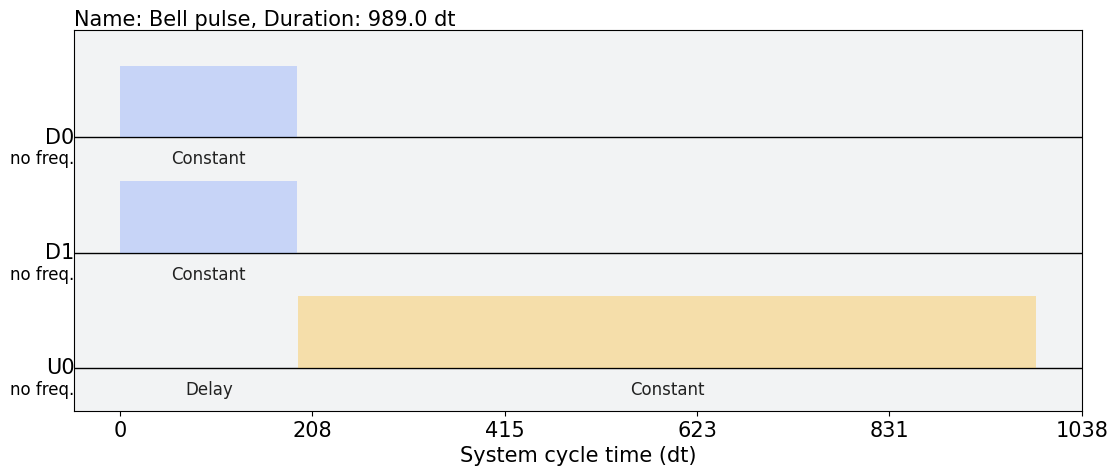

In [35]:
esque_pul(parametros_optimos_2).draw()

In [290]:
objective_12(parametros_optimos_2).draw("latex")

<IPython.core.display.Latex object>

In [291]:
negativity(objective_12(parametros_optimos_2),[0])
# (concurrence(partial_trace(objective_12(tt),[0]))**2 + concurrence(partial_trace(objective_12(tt),[1]))**2 + concurrence(partial_trace(objective_12(tt),[2]))**2)/3


np.float64(0.49984039469001074)

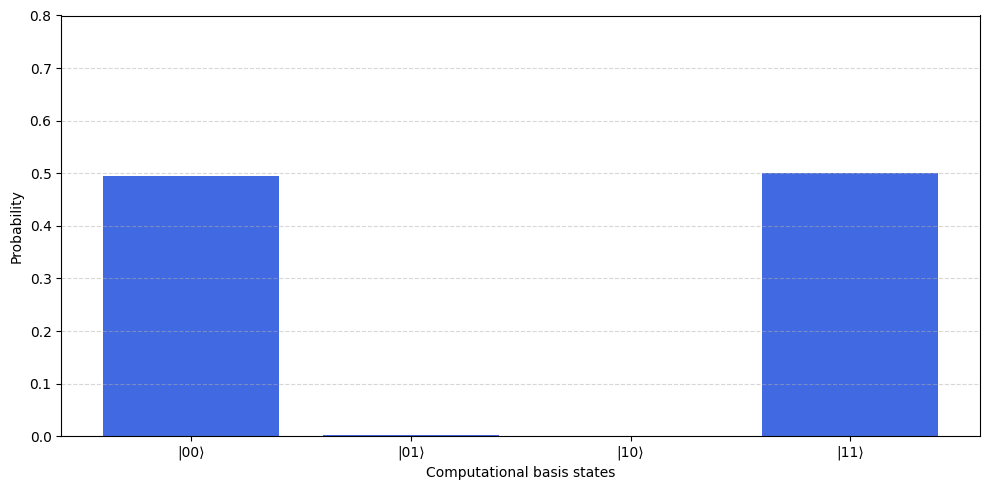

In [292]:
plot_statevector_probabilities(objective_12(parametros_optimos_2))

In [293]:
def evol_12(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver_closed.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        atol=1e-10,
        rtol=1e-8
    )
   
    return sol

In [294]:
evol = evol_12(parametros_optimos_2)

In [295]:
nega_closed = []
for i in range(len(evol.t)):
    nega_closed.append(negativity(evol.y[i],[1]))

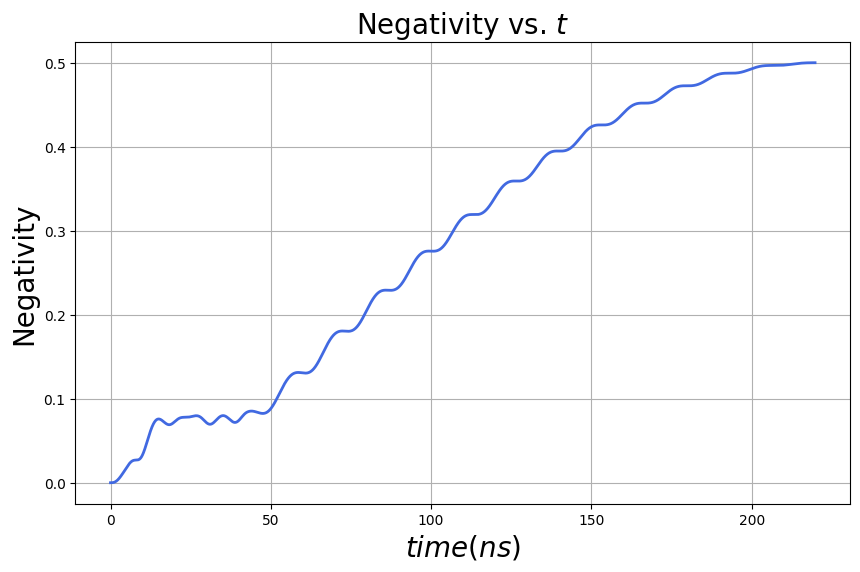

In [296]:
fontsize = 20

_, ax = plt.subplots(figsize = (10, 6))
# plt.rcParams.update({'font.size': fontsize})
plt.plot(evol.t,  nega_closed, color = 'royalblue', linewidth = 2, label = 'Negativity')
# plt.legend(fontsize = fontsize)
ax.set_ylabel("Negativity", fontsize = fontsize)
ax.set_xlabel('$time (ns)$', fontsize = fontsize)
ax.set_title('Negativity vs. $t$', fontsize = fontsize)
ax.grid()

In [197]:
solver_open =  solver = Solver(static_hamiltonian=static_ham,
                hamiltonian_operators= [H_drive7, H_drive8, H_drive7],
                static_dissipators = collapse_operators,
                dissipator_channels= None,
                hamiltonian_channels=['d0', 'd1', 'u0'],
                channel_carrier_freqs= {"d0": v7, "d1": v8, "u0": v8 },
                dt=dt,
                array_library='jax'
                )

In [198]:
from qiskit import pulse

def esque_pul(params):
    t_0, t_1,A0, A1, A2  = params

    # Convertir a enteros por requerimiento del backend
    t_0 = int(t_0)
    t_1 = int(t_1)
  
    with pulse.build(name="pulso 2q") as kp:
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
    

        # Primer pulso en d0 y d1
        pulse.play(pulse.Constant(duration=t_0, amp=A0), d0)
        pulse.play(pulse.Constant(duration=t_0, amp=A1), d1)   
        # Delay en canal u0
        pulse.delay(duration= t_0 + 1, channel=u0)
        # Segundo pulso en d1 y u0
        pulse.play(pulse.Constant(duration = t_1 , amp=A2), u0)
        # delay pulso d2 y u1        
    return kp

# %%
parametros_optimos = [
          332.62472447863985,
          680.4137630830777,
          0.6173140947022615,
          0.6487042324680496,
          0.9208267387996893
     ]

In [199]:
def sanitize_density_matrix(rho):
    """
    Corrige una matriz para que sea una matriz densidad física:
    - Hermítica
    - Traza 1
    - Semidefinida positiva
    """
    rho = np.array(rho, dtype=complex)

    # 1) Forzar hermiticidad
    rho = 0.5 * (rho + rho.conj().T)

    # 2) Diagonalizar
    eigvals, eigvecs = np.linalg.eigh(rho)

    # 3) Eliminar negativos pequeños
    eigvals[eigvals < 0] = 0

    # 4) Reconstruir
    rho = eigvecs @ np.diag(eigvals) @ eigvecs.conj().T

    # 5) Renormalizar traza
    rho = rho / np.trace(rho)

    return DensityMatrix(rho)

In [200]:
def objective_bell_lindblab(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        method="jax_odeint",
        atol=1e-11,
        rtol=1e-11
    )
    yf = sol.y[-1]
    density_matrix = sanitize_density_matrix(yf)
    cost = (0.5 - negativity(density_matrix,[0]))**2
    return cost

In [201]:
def estado_bell_lindblab(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]
    density_matrix = sanitize_density_matrix(yf)
    
    return density_matrix


def evol_bell_lindblab(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    
    return sol

In [202]:
solu = estado_bell_lindblab(parametros_optimos)

In [203]:
evol_open = evol_bell_lindblab(parametros_optimos)

In [204]:
sanitize_density_matrix(evol_open.y[-1])

DensityMatrix([[ 0.32601665-4.52438991e-18j, -0.22710342-1.22329341e-01j,
                -0.01876268-2.51011813e-01j,  0.12199082-2.56065029e-01j],
               [-0.22710342+1.22329341e-01j,  0.21327922+1.09179440e-17j,
                 0.10847899+1.71668889e-01j,  0.01330464+2.28212310e-01j],
               [-0.01876268+2.51011813e-01j,  0.10847899-1.71668889e-01j,
                 0.20242294-2.80918256e-18j,  0.19583096+1.08794298e-01j],
               [ 0.12199082+2.56065029e-01j,  0.01330464-2.28212310e-01j,
                 0.19583096-1.08794298e-01j,  0.25828119-3.58437157e-18j]],
              dims=(2, 2))


In [205]:
Density_matrix = []
for i in range(len(evol_open.y)):
    Density_matrix.append(sanitize_density_matrix(evol_open.y[i]))

In [206]:
nega_open = []
for i in range(len(Density_matrix)):
    nega_open.append(negativity(Density_matrix[i], [1]))

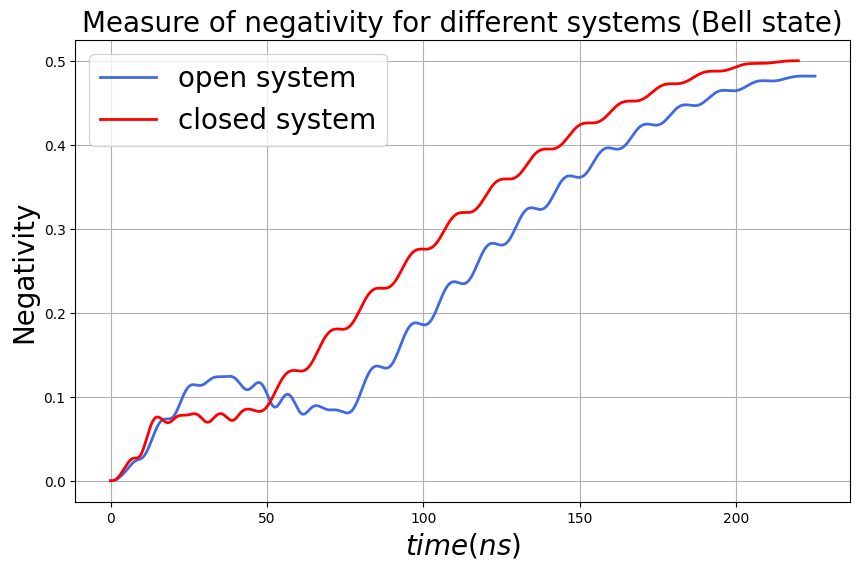

In [207]:
fontsize = 20

_, ax = plt.subplots(figsize = (10, 6))
# plt.rcParams.update({'font.size': fontsize})
plt.plot(evol_open.t,  nega_open, color = 'royalblue', linewidth = 2, label = 'open system')
plt.plot(evol.t,  nega_closed, color = 'red', linewidth = 2, label = 'closed system')
plt.legend(fontsize = fontsize)
ax.set_ylabel("Negativity", fontsize = fontsize)
ax.set_xlabel('$time (ns)$', fontsize = fontsize)
ax.set_title('Measure of negativity for different systems (Bell state)', fontsize = fontsize)
ax.grid()

In [1]:
for i in range(len(evol_open.t)):
    print(i)

NameError: name 'evol_open' is not defined